In [6]:
import pandas as pd
import numpy as np

path = "../../../src/matlab/data/result/statistical_tests/wlnm_dir_neg_delta_ttests.csv"
df = pd.read_csv(path)

df["Cohen_dz"] = df["MeanDelta"] / df["StdDelta"]
df["MinusLog10P"] = -np.log10(df["PValue"])
df["Direction"] = np.where(df["MeanDelta"] >= 0, "Generated > empirical", "Generated < empirical")

print(df[[
    "Metric", "NumFoodWebs", "MeanDelta", "StdDelta",
    "TStatistic", "DF", "PValue", "RejectH0", "Cohen_dz", "Direction"
]].sort_values("PValue"))


              Metric  NumFoodWebs  MeanDelta    StdDelta  TStatistic  DF  \
1        Connectance            3  -0.022516    0.019891   -1.960633   2   
3         MeanDegree            3  -1.871327    2.415700   -1.341737   2   
4     MeanGenerality            3  -1.600283    2.155513   -1.285899   2   
0              Links            3 -66.333333  104.500399   -1.099448   2   
6          PropBasal            3  -0.051282    0.088823   -1.000000   2   
7   PropIntermediate            3  -0.051282    0.088823   -1.000000   2   
8            PropTop            3   0.025641    0.044412    1.000000   2   
5  MeanVulnerability            3  -0.769459    1.498546   -0.889357   2   
2   MeanTrophicLevel            3  -0.046757    0.093583   -0.865392   2   

     PValue  RejectH0  Cohen_dz              Direction  
1  0.188968         0 -1.131972  Generated < empirical  
3  0.311727         0 -0.774652  Generated < empirical  
4  0.327256         0 -0.742414  Generated < empirical  
0  0.386232

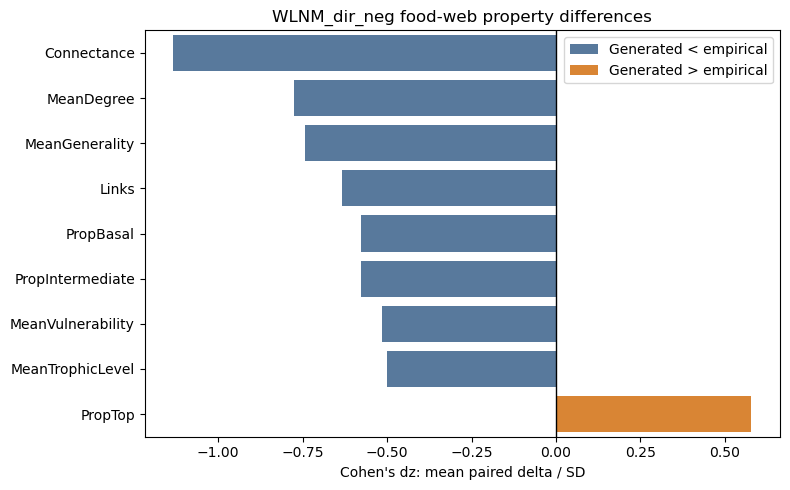

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = df.sort_values("Cohen_dz")

plt.figure(figsize=(8, 5))
sns.barplot(
    data=plot_df,
    y="Metric",
    x="Cohen_dz",
    hue="Direction",
    dodge=False,
    palette={
        "Generated < empirical": "#4C78A8",
        "Generated > empirical": "#F58518",
    }
)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Cohen's dz: mean paired delta / SD")
plt.ylabel("")
plt.title("WLNM_dir_neg food-web property differences")
plt.legend(title="")
plt.tight_layout()
plt.show()


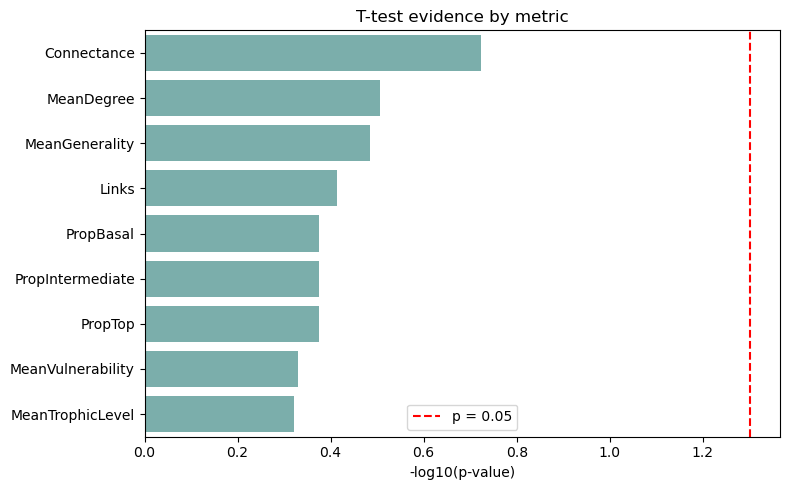

In [8]:
plot_df = df.sort_values("PValue")

plt.figure(figsize=(8, 5))
sns.barplot(data=plot_df, y="Metric", x="MinusLog10P", color="#72B7B2")
plt.axvline(-np.log10(0.05), color="red", linestyle="--", label="p = 0.05")
plt.xlabel("-log10(p-value)")
plt.ylabel("")
plt.title("T-test evidence by metric")
plt.legend()
plt.tight_layout()
plt.show()


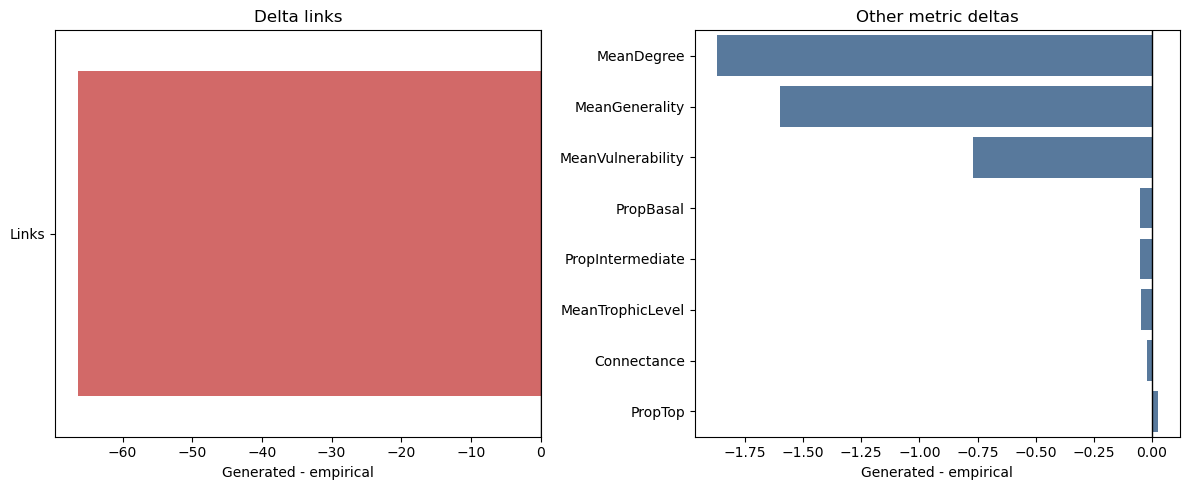

In [9]:
links = df[df["Metric"].eq("Links")]
others = df[~df["Metric"].eq("Links")].sort_values("MeanDelta")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=links, y="Metric", x="MeanDelta", color="#E45756", ax=axes[0])
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title("Delta links")
axes[0].set_xlabel("Generated - empirical")

sns.barplot(data=others, y="Metric", x="MeanDelta", color="#4C78A8", ax=axes[1])
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("Other metric deltas")
axes[1].set_xlabel("Generated - empirical")

for ax in axes:
    ax.set_ylabel("")

plt.tight_layout()
plt.show()


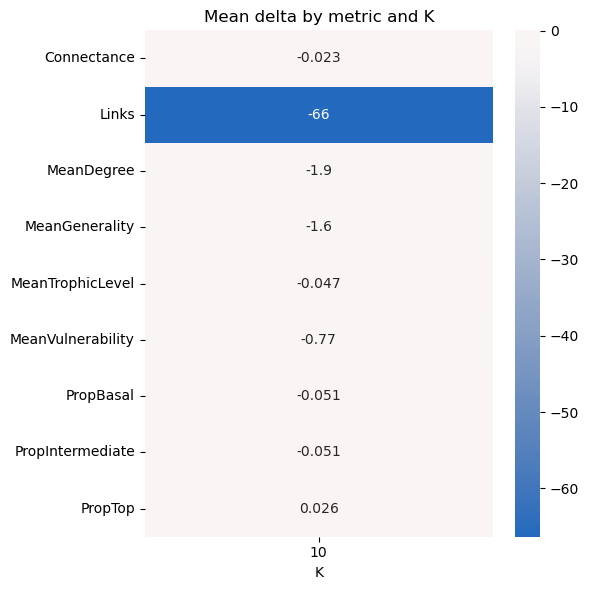

In [10]:
heat = df.pivot_table(
    index="Metric",
    columns="K",
    values="MeanDelta",
    aggfunc="mean"
)

plt.figure(figsize=(6, 6))
sns.heatmap(heat, annot=True, cmap="vlag", center=0)
plt.title("Mean delta by metric and K")
plt.xlabel("K")
plt.ylabel("")
plt.tight_layout()
plt.show()


In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

result_dir = Path("../../../src/matlab/data/result/prediction_scores_logs")

files = list(result_dir.glob("*_results_random_wlnm_dir_neg.csv"))

rows = []
for file in files:
    df = pd.read_csv(file)
    df["FoodWeb"] = file.name.replace("_tax_mass_results_random_wlnm_dir_neg.csv", "")
    rows.append(df)

raw = pd.concat(rows, ignore_index=True)

delta_cols = [
    "DeltaLinks",
    "DeltaConnectance",
    "DeltaMeanTrophicLevel",
    "DeltaMeanDegree",
    "DeltaMeanGenerality",
    "DeltaMeanVulnerability",
    "DeltaPropBasal",
    "DeltaPropIntermediate",
    "DeltaPropTop",
]

long = raw.melt(
    id_vars=["FoodWeb", "K", "TrainRatio", "ThresholdMode"],
    value_vars=delta_cols,
    var_name="Metric",
    value_name="Delta"
)

long["Metric"] = long["Metric"].str.replace("Delta", "", regex=False)


/var/folders/fh/0vq0142d1t36s502_bgq3z480000gp/T/ipykernel_42536/3263702154.py:20: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(


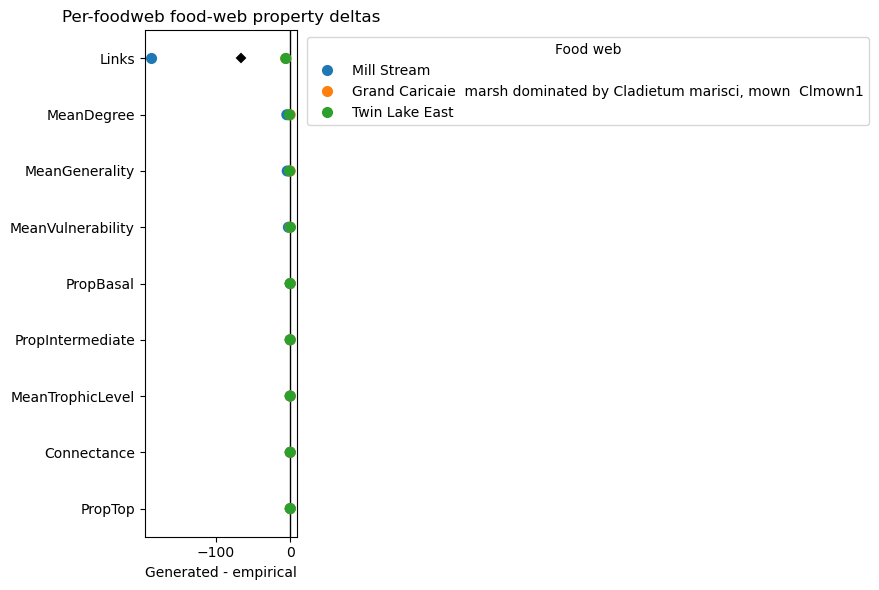

In [12]:
plt.figure(figsize=(9, 6))

order = (
    long.groupby("Metric")["Delta"]
    .mean()
    .sort_values()
    .index
)

sns.stripplot(
    data=long,
    y="Metric",
    x="Delta",
    order=order,
    hue="FoodWeb",
    size=8,
    jitter=False
)

sns.pointplot(
    data=long,
    y="Metric",
    x="Delta",
    order=order,
    errorbar=None,
    color="black",
    markers="D",
    linestyles="none",
    scale=0.7
)

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Generated - empirical")
plt.ylabel("")
plt.title("Per-foodweb food-web property deltas")
plt.legend(title="Food web", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


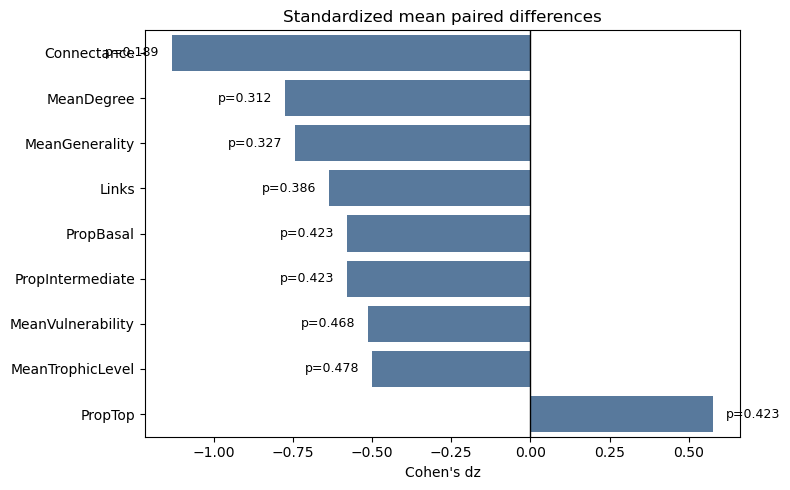

In [13]:
summary = pd.read_csv(
    "../../../src/matlab/data/result/statistical_tests/wlnm_dir_neg_delta_ttests.csv"
)

summary["Cohen_dz"] = summary["MeanDelta"] / summary["StdDelta"]
summary = summary.sort_values("Cohen_dz")

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=summary,
    y="Metric",
    x="Cohen_dz",
    color="#4C78A8"
)

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Cohen's dz")
plt.ylabel("")
plt.title("Standardized mean paired differences")

for i, row in enumerate(summary.itertuples()):
    x = row.Cohen_dz
    label_x = x - 0.04 if x < 0 else x + 0.04
    ha = "right" if x < 0 else "left"
    ax.text(label_x, i, f"p={row.PValue:.3f}", va="center", ha=ha, fontsize=9)

plt.tight_layout()
plt.show()
